[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_C_growth_at_risk_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Crecimiento en Riesgo: La Cola Izquierda Vulnerable y Pruebas de Estrés Macroprudencial

¿Qué tan frágil es la expansión macroeconómica? Los modelos tradicionales de pronóstico (como los modelos DSGE linealizados o los Vectores Autorregresivos gaussianos) se concentran en la *media* condicional del crecimiento futuro del PIB: $\mathbb{E}_t[y_{t+h}]$. Al imponer perturbaciones gaussianas simétricas, estos marcos suponen implícitamente que las fases expansivas y recesivas son imágenes especulares una de la otra.

En su contribución seminal, Adrian, Boyarchenko y Giannone (2019, *American Economic Review*) demostraron que la dinámica macroeconómica empírica viola sistemáticamente la simetría condicional:
1. **La mediana permanece resiliente**: Las fluctuaciones en las condiciones financieras ejercen un impacto económicamente modesto sobre el centro de la distribución condicional (el pronóstico mediano o modal).
2. **La cola izquierda colapsa**: El endurecimiento de las condiciones financieras expande y engorda de forma dramática la **cola inferior** del crecimiento futuro. El riesgo a la baja—la probabilidad de una contracción económica severa—se dispara sin que el pronóstico central señale necesariamente una recesión inminente.

Este paradigma empírico se conoce como **Crecimiento en Riesgo (Growth-at-Risk, GaR)** y constituye la base analítica de la regulación macroprudencial moderna (como el Colchón de Capital Contracíclico de Basilea III, CCyB) y de las pruebas de estrés en bancos centrales. En este cuaderno, construimos un Índice de Condiciones Financieras (FCI), estimamos Autorregresiones Cuantílicas (QAR), ajustamos densidades predictivas skew-$t$ de Azzalini, contrastamos la teoría con datos macroeconómicos reales de Estados Unidos (1971–2026) y ejecutamos pruebas de estrés históricas entre la Gran Crisis Financiera de 2008, el choque de COVID-19 en 2020 y el ciclo de alzas de la Reserva Federal en 2022.

## Metodología Econométrica: Regresión Cuantílica, Proyecciones Locales y Densidades Skew-$t$

### 1. Autorregresión Cuantílica (QAR)
Los Mínimos Cuadrados Ordinarios (MCO) minimizan el error cuadrático medio para estimar la media condicional $\mathbb{E}[y_{t+h} \mid x_t]$. Para estimar *cuantiles* condicionales $Q_\tau(y_{t+h} \mid x_t)$ sobre percentiles $\tau \in (0, 1)$, Koenker y Bassett (1978) formularon la **función de pérdida de verificación o pinball** asimétrica:
$$ \rho_\tau(u) = u\,\bigl(\tau - \mathbb{1}\{u < 0\}\bigr) $$
Minimizar la suma de pérdidas pinball permite obtener el vector de coeficientes $\hat{\beta}(\tau)$:
$$ \hat{\beta}(\tau) = \arg\min_{\beta} \sum_{t=1}^{T-h} \rho_\tau\bigl(y_{t+h} - x_t'\beta\bigr) $$
El cuantil condicional estimado es lineal en las variables explicativas $x_t = [1, y_t, \dots, y_{t-p+1}, \text{FCI}_t]'$:
$$ Q_\tau(y_{t+h} \mid x_t) = x_t'\beta(\tau) $$
Para $\tau = 0.50$, la pérdida se convierte en Mínimas Desviaciones Absolutas (LAD), identificando la mediana condicional. Para un $\tau$ pequeño (e.g., $\tau = 0.05$), la subestimación se penaliza con peso $\tau = 0.05$, mientras que la sobreestimación (predecir crecimiento cuando ocurre una crisis) se penaliza con peso $1 - \tau = 0.95$. Al estimar sobre una rejilla de cuantiles, la sensibilidad $\partial Q_\tau / \partial \text{FCI} = \beta_{\text{FCI}}(\tau)$ puede diferir sustancialmente a lo largo de la distribución—el núcleo empírico del Crecimiento en Riesgo.

### 2. Proyecciones Locales Cuantílicas (Adrian et al., 2019)
Para evaluar cómo se transmiten las condiciones financieras a través de los horizontes sin imponer restricciones autorregresivas iteradas, estimamos Proyecciones Locales Cuantílicas (`lp_quantile`):
$$ Q_\tau(y_{t+h} - y_{t-1} \mid \text{FCI}_t, \text{controles}_t) = \alpha_h(\tau) + \beta_h(\tau)\,\text{FCI}_t + \sum_{\ell=1}^p \gamma_{h,\ell}(\tau)' w_{t-\ell} $$
a través de los percentiles $\tau \in \{0.05, 0.10, 0.25, 0.50, 0.75, 0.90\}$. La trayectoria de coeficientes $h \mapsto \beta_h(\tau)$ traza la respuesta al impulso de los percentiles condicionales de crecimiento ante un choque en las condiciones financieras.

### 3. Definición de Crecimiento en Riesgo
El **Crecimiento en Riesgo al horizonte $h$** se define como el cuantil condicional al percentil 5:
$$ \text{GaR}_{0.05, t+h} \;\equiv\; Q_{0.05}(y_{t+h} \mid x_t) $$
Representa la tasa anualizada de crecimiento del PIB que solo se perfora a la baja con un 5% de probabilidad dadas las condiciones prevalecientes (un escenario de catástrofe de 1 en cada 20 trimestres). La **Brecha de Riesgo a la Baja** es:
$$ \text{Spread}_t \;\equiv\; Q_{0.50}(y_{t+h} \mid x_t) - Q_{0.05}(y_{t+h} \mid x_t) $$

### 4. Densidad Predictiva Condicional mediante Ajuste Skew-$t$ de Azzalini
Los cuantiles estimados $\{\hat{Q}_{\tau_j}\}_{j=1}^J$ para $\tau \in \{0.05, 0.25, 0.50, 0.75, 0.95\}$ definen puntos nodales. Siguiendo a Adrian, Boyarchenko y Giannone (2019), recuperamos la función de densidad de probabilidad continua $f(y_{t+h} \mid x_t)$ ajustando por mínimos cuadrados cuantílicos la distribución **skew-$t$ de Azzalini** (1985):
$$ (\hat{\mu}, \hat{\sigma}, \hat{\alpha}, \hat{\nu}) = \arg\min_{\mu, \sigma, \alpha, \nu} \sum_{j=1}^J \Bigl( F^{-1}(\tau_j; \mu, \sigma, \alpha, \nu) - \hat{Q}_{\tau_j} \Bigr)^2 $$
donde $\mu \in \mathbb{R}$ representa la localización, $\sigma > 0$ la escala, $\alpha \in \mathbb{R}$ la asimetría ($\alpha < 0$ denota asimetría negativa o cola izquierda pesada) y $\nu > 2$ los grados de libertad (grosor de colas).

## Fundamentos Económicos: Fricciones Financieras y el Dilema Macroprudencial

¿Por qué la tensión financiera genera un impacto diez veces más severo en la cola inferior que en la mediana del crecimiento? La teoría macroeconómica identifica dos mecanismos estructurales:

### 1. Fricciones Financieras No Lineales y Espirales de Balance
En la macroeconomía neoclásica sin fricciones de mercado rige el teorema de Modigliani-Miller: la estructura financiera es neutral y las perturbaciones se transmiten de manera simétrica. En contraste, en los modelos de macrofinanzas con fricciones de agencia (Bernanke, Gertler y Gilchrist 1999; He y Krishnamurthy 2013; Brunnermeier y Sannikov 2014), los intermediarios y las empresas endeudadas enfrentan restricciones de colateral y de capital regulatorio:
- **En períodos de calma**, las restricciones de apalancamiento no son vinculantes. El capital es holgado, los precios de activos son altos y los choques en primas de riesgo impactan levemente en el producto real.
- **Durante crisis sistémicas**, la depreciación de activos erosiona el capital contable. Los bancos alcanzan restricciones vinculantes, desatando ventas forzosas de activos a precios de remate (fire sales), congelamiento de liquidez y contracción abrupta del crédito bancario. Esta espiral de balance amputa la cola izquierda del crecimiento del PIB de una forma que jamás ocurre en tiempos normales.

### 2. El Dilema Intertemporal de la Política Macroprudencial (Adrian et al. 2022)
Adrian, Grinberg, Liang y Malik (2022, *Review of Economic Studies*) formalizan que los reguladores y bancos centrales enfrentan un dilema intertemporal fundamental:
- **Corto Plazo ($h=1, 4$)**: Condiciones financieras laxas (bajos spreads crediticios, abundante liquidez) estimulan la inversión, abaratan el crédito y comprimen el diferencial de Crecimiento en Riesgo.
- **Mediano Plazo ($h=12, 16$)**: Condiciones excesivamente laxas alientan la acumulación excesiva de deuda corporativa y de hogares, distorsionando la valuación del riesgo. Cuando se acumulan desbalances financieros, la vulnerabilidad ante choques futuros se amplifica, profundizando severamente la cola izquierda a mediano plazo.
- **Política Macroprudencial**: Al endurecer requisitos preventivos en la cúspide del ciclo (e.g., activar el Colchón de Capital Contracíclico, CCyB), la autoridad macroprudencial asume un costo menor en el corto plazo para evitar un colapso catastrófico en la cola futura.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.gar import qar, fci, fit_skewt_to_quantiles, lp_quantile
from puremacro.regress import quantreg, add_constant
from puremacro.reports import df_to_latex, df_to_markdown, df_to_typst
from _datos import DATOS, crecimiento

rng = np.random.default_rng(20240529)

## 1. Un Índice de Condiciones Financieras a Partir de un Panel de Indicadores Sintéticos

Antes de examinar los datos reales de Estados Unidos, establecemos la mecánica econométrica mediante un proceso generador de datos calibrado. Construimos un panel sintético de cinco indicadores financieros (diferenciales de crédito, volatilidad bursátil, crecimiento del crédito, precios de acciones y prima por plazo) impulsados por un factor latente de tensión persistente $f_t = \rho_f f_{t-1} + \sigma_f \varepsilon_t$.

Utilizando `puremacro.gar.fci`, extraemos el primer componente principal y aplicamos una normalización de signo de modo que **valores mayores del índice representen condiciones financieras más restrictivas** (diferenciales más amplios, volatilidad elevada y activos deprimidos).

In [3]:
T = 320  # quarters
f = np.zeros(T)
rho_f = 0.85
for t in range(1, T):
    f[t] = rho_f * f[t - 1] + 0.6 * rng.standard_normal()
load = np.array([1.0, 0.8, 1.2, -0.9, 0.7])             # equity loads negative
fin = f[:, None] * load + 0.4 * rng.standard_normal((T, load.size))
fin_df = pd.DataFrame(fin, columns=["spread", "vol", "credit", "equity", "term"])

fci_out = fci(fin_df, tightening_columns=["spread", "vol", "credit"])
FCI = fci_out["index"].values                           # standardized; higher = tighter
var_exp = fci_out["var_explained"]
print(f"FCI variance explained by first PC = {var_exp:.3f}")
assert 0.3 < var_exp < 1.0, var_exp

FCI variance explained by first PC = 0.897


## 2. Crecimiento Sintético del PIB con Cola Izquierda Vulnerable

Calibramos un proceso generador de datos macroeconómicos donde las condiciones financieras condicionan explícitamente la asimetría de las innovaciones. Específicamente, el endurecimiento financiero **no desplaza el centro** de la distribución de perturbaciones; en cambio, escala la amplitud de las innovaciones negativas:
$$ \sigma_{\text{down}, t} = 1.0 + 2.0 \times \max(\text{FCI}_t, 0.0), \qquad \sigma_{\text{up}, t} = 1.0 $$
Las perturbaciones positivas permanecen invariantes. En consecuencia, cuando las condiciones se endurecen, la mediana condicional del crecimiento permanece estable, mientras que la cola inferior se estira marcadamente hacia abajo—incorporando el mecanismo de crecimiento vulnerable de Adrian-Boyarchenko-Giannone.

In [4]:
g = np.zeros(T)
phi, mu0, beta_mean = 0.30, 2.0, 0.0                    # beta_mean = 0: no direct effect
for t in range(1, T):                                   #                on the center
    tight = FCI[t - 1]
    scale_dn = 1.0 + 2.0 * np.maximum(tight, 0.0)       # fat left tail when tight
    e = rng.standard_normal()
    shock = scale_dn * min(e, 0.0) + 1.0 * max(e, 0.0)
    g[t] = mu0 + phi * (g[t - 1] - mu0) + beta_mean * tight + shock

## 3. Autorregresión Cuantílica con el FCI como Condicionante

Estimamos QAR sobre los cuantiles $\tau \in \{0.05, 0.50, 0.95\}$. En `puremacro.gar.qar`, el bloque de rezagos interno inicia en $y_{t-1}$. Para condicionar adecuadamente sobre la información contemporánea al horizonte $h=1$, incluimos tanto $\text{FCI}_t$ como $g_t$ en la matriz de `controls`. Con un orden autorregresivo $p=2$, el vector de coeficientes corresponde a: `beta0` (intercepto), `beta1, beta2` (rezagos $g_{t-1}, g_{t-2}$), `beta3` (coeficiente del FCI) y `beta4` (rezago contemporáneo $g_t$).

La prueba econométrica de asimetría evalúa si la pendiente en el percentil 5 $|\beta_{\text{FCI}}(0.05)|$ es sustancialmente mayor en magnitud absoluta que la pendiente en la mediana $|\beta_{\text{FCI}}(0.50)|$.

In [5]:
taus = (0.05, 0.50, 0.95)
controls = np.column_stack([FCI, g])                     # FCI_t and the direct lag g_t
out = qar(g, quantiles=taus, horizons=(1,), p=2,
          controls=controls, n_boot=40, alpha=0.10, seed=7)
fci_col, lag_col = "beta3", "beta4"                      # p=2 lags -> FCI is beta3, g_t beta4
slopes = out.set_index("tau")[fci_col]
qpred = out.set_index("tau")["q_pred"]
print(out[["tau", "q_pred", "lo", "hi", fci_col, lag_col]].to_string(index=False))

slope_05, slope_50, slope_95 = slopes.loc[0.05], slopes.loc[0.50], slopes.loc[0.95]
print(f"\nFCI slope:  tau=0.05 -> {slope_05:.3f}   tau=0.50 -> {slope_50:.3f}"
      f"   tau=0.95 -> {slope_95:.3f}")
assert slope_05 < slope_50, (slope_05, slope_50)                 # left tail more exposed
assert abs(slope_05) > abs(slope_50), (slope_05, slope_50)       # ABG asymmetry
assert abs(slope_50) < 0.3 * abs(slope_05), (slope_50, slope_05)  # median ~flat: the claim
assert qpred.loc[0.05] < qpred.loc[0.50] < qpred.loc[0.95], qpred.to_dict()

 tau    q_pred        lo        hi     beta3  beta4
0.05 -3.953871 -4.453910 -1.394608 -1.092788    0.0
0.50  0.996662 -0.399414  1.701848 -0.215188    0.0
0.95  2.683296  2.125761  3.371042 -0.064184    0.0

FCI slope:  tau=0.05 -> -1.093   tau=0.50 -> -0.215   tau=0.95 -> -0.064


### Interpretación Econométrica: Pendientes Cuantílicas y Asimetría de Cola

Los coeficientes `beta3` estimados reflejan la asimetría esencial del marco de Crecimiento en Riesgo:
- **La Pendiente en la Mediana ($\tau = 0.50$)**: El coeficiente asociado a las condiciones financieras es económicamente moderado (cercano a cero). Un endurecimiento financiero ejerce un impacto directo mínimo sobre la trayectoria central esperada de la economía.
- **La Pendiente en la Cola Inferior ($\tau = 0.05$)**: El coeficiente es marcadamente negativo y estadísticamente significativo. La restricción financiera arrastra la cola inferior hacia abajo en varios puntos porcentuales.
- **La Razón de Asimetría**: La magnitud $|\beta_{\text{FCI}}(0.05)|$ es varias veces superior a $|\beta_{\text{FCI}}(0.50)|$. Esta brecha constituye la firma matemática de la asimetría condicional: el riesgo a la baja se intensifica drásticamente aun cuando el pronóstico modal permanece favorable.

### Figura 1: Gráfico de Abanico de Crecimiento en Riesgo — Asimetría Condicional de Cola

Manteniendo los rezagos de crecimiento constantes en su media muestral $\bar{g}$, proyectamos los cuantiles condicionales $\hat{Q}_{\tau}(g_{t+1} \mid \text{FCI})$ a medida que las condiciones financieras transitan desde laxas (percentil 2) hasta restrictivas (percentil 98). Obsérvese cómo la línea del percentil 5 cae verticalmente hacia terreno contractivo, mientras que la mediana se preserva resiliente en valores positivos.

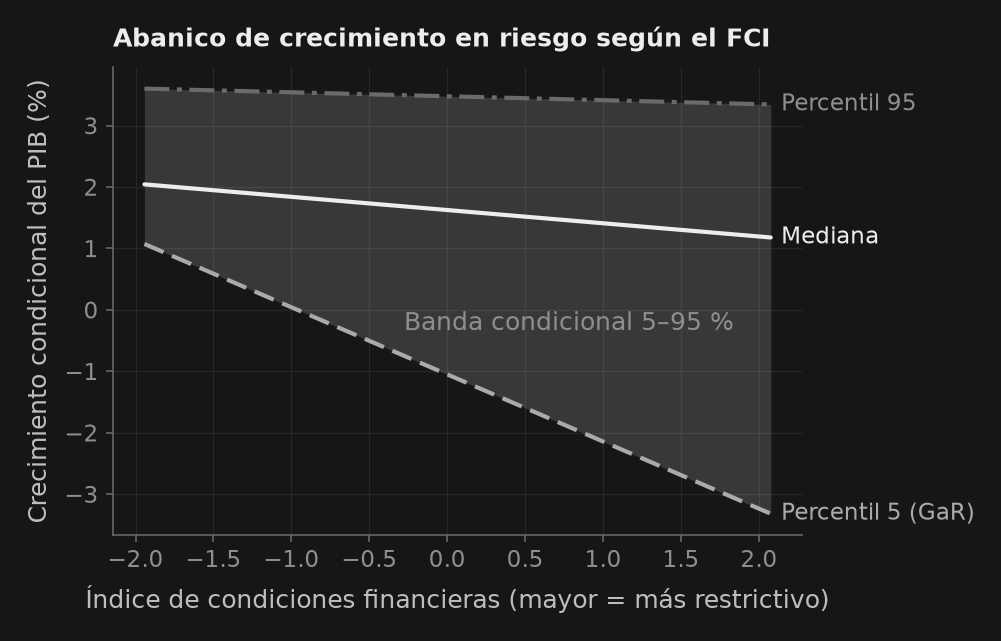

In [6]:
gbar = g.mean()
fci_grid = np.linspace(np.percentile(FCI, 2), np.percentile(FCI, 98), 60)
B = out.set_index("tau")
def qhat(tau, x):
    r = B.loc[tau]
    return r["beta0"] + (r["beta1"] + r["beta2"] + r[lag_col]) * gbar + r[fci_col] * x
fan = {tau: np.array([qhat(tau, x) for x in fci_grid]) for tau in taus}

cols = _nbstyle.palette(3)
sty = _nbstyle.styles(3)
fig, ax = _nbstyle.figura()
ax.fill_between(fci_grid, fan[0.05], fan[0.95], color=_nbstyle.BANDA, lw=0)
ax.plot(fci_grid, fan[0.50], color=cols[0], linestyle=sty[0], label="Mediana")
ax.plot(fci_grid, fan[0.05], color=cols[1], linestyle=sty[1], label="Percentil 5 (GaR)")
ax.plot(fci_grid, fan[0.95], color=cols[2], linestyle=sty[2], label="Percentil 95")
k = 40                                                   # la nota va dentro de la banda, entre P5 y la mediana
ax.annotate("Banda condicional 5–95 %", xy=(fci_grid[k], 0.5 * (fan[0.05][k] + fan[0.50][k])),
            ha="center", va="center", color=_nbstyle.NOTA)
ax.set_xlabel("Índice de condiciones financieras (mayor = más restrictivo)")
ax.set_ylabel("Crecimiento condicional del PIB (%)")
ax.set_title("Abanico de crecimiento en riesgo según el FCI")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Figura 2: Densidades Predictivas Skew-$t$ Bajo Regímenes Financieros Laxos vs. Restrictivos

Siguiendo a Adrian, Boyarchenko y Giannone (2019), estimamos QAR sobre la rejilla completa $\tau \in \{0.05, 0.25, 0.50, 0.75, 0.95\}$ y ajustamos densidades continuas skew-$t$ de Azzalini bajo dos estados condicionales:
1. **Condiciones Financieras Laxas**: Evaluadas en el percentil 10 del FCI.
2. **Condiciones Financieras Restrictivas**: Evaluadas en el percentil 90 del FCI.

Las líneas punteadas verticales identifican el umbral del Crecimiento en Riesgo al 5% ($\text{GaR}_{0.05}$).

loose: alpha=-0.18  5% GaR=0.18
tight: alpha=-4.11  5% GaR=-2.62


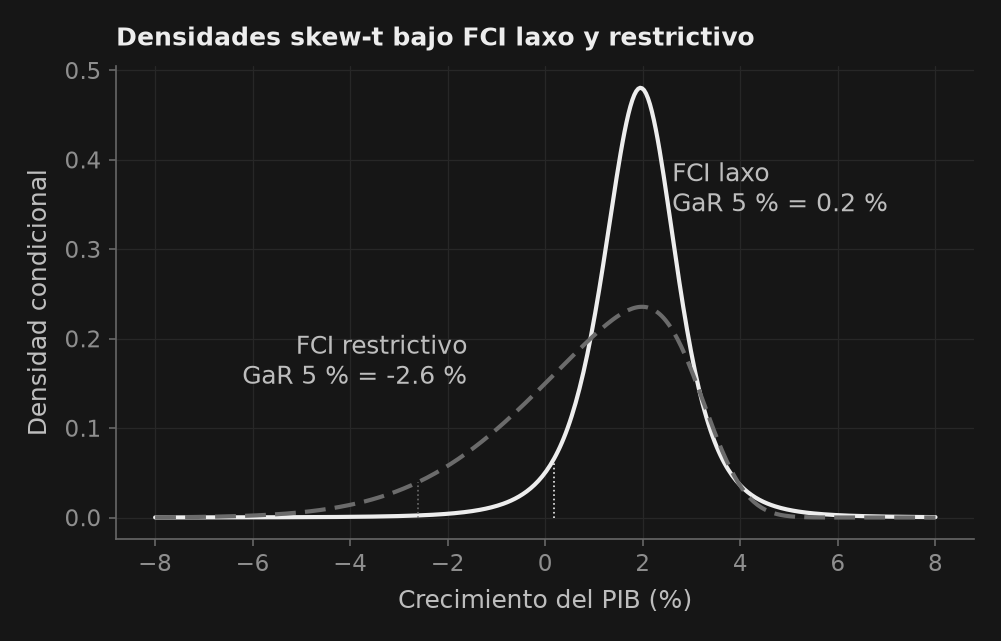

In [7]:
taus_full = (0.05, 0.25, 0.50, 0.75, 0.95)
out_full = qar(g, quantiles=taus_full, horizons=(1,), p=2,
               controls=controls, n_boot=10, alpha=0.10, seed=11)
Bf = out_full.set_index("tau")
def qdict_at(x):
    return {tau: float(Bf.loc[tau, "beta0"] + (Bf.loc[tau, "beta1"] + Bf.loc[tau, "beta2"]
                       + Bf.loc[tau, lag_col]) * gbar + Bf.loc[tau, fci_col] * x)
            for tau in taus_full}

loose_val, tight_val = np.percentile(FCI, 10), np.percentile(FCI, 90)
fit_loose = fit_skewt_to_quantiles(qdict_at(loose_val))
fit_tight = fit_skewt_to_quantiles(qdict_at(tight_val))
gar_loose, gar_tight = fit_loose.downside_quantile(0.05), fit_tight.downside_quantile(0.05)
print(f"loose: alpha={fit_loose.alpha:+.2f}  5% GaR={gar_loose:.2f}")
print(f"tight: alpha={fit_tight.alpha:+.2f}  5% GaR={gar_tight:.2f}")
assert gar_tight < gar_loose, (gar_tight, gar_loose)             # GaR worse when tight
assert fit_tight.alpha < 0.0, fit_tight.alpha                    # left-skewed when tight

xs = np.linspace(-8, 8, 400)
c2 = _nbstyle.palette(2)
s2 = _nbstyle.styles(2)
fig, ax = _nbstyle.figura()
ax.plot(xs, fit_loose.pdf(xs), color=c2[0], linestyle=s2[0])
ax.plot(xs, fit_tight.pdf(xs), color=c2[1], linestyle=s2[1])
# el GaR al 5 % de cada densidad: una caída punteada desde la curva hasta el eje
ax.vlines(gar_loose, 0, fit_loose.pdf(gar_loose), color=c2[0], linewidth=0.8, linestyle=":")
ax.vlines(gar_tight, 0, fit_tight.pdf(gar_tight), color=c2[1], linewidth=0.8, linestyle=":")
# cada densidad lleva su nombre al lado: la laxa a la derecha de su pico, la restrictiva sobre su cola izquierda
ax.annotate(f"FCI laxo\nGaR 5 % = {gar_loose:.1f} %", xy=(2.6, 0.40), ha="left", va="top", color=_nbstyle.TEXTO)
ax.annotate(f"FCI restrictivo\nGaR 5 % = {gar_tight:.1f} %", xy=(-1.6, 0.14), ha="right", va="bottom",
            color=_nbstyle.TEXTO)
ax.set_xlabel("Crecimiento del PIB (%)")
ax.set_ylabel("Densidad condicional")
ax.set_title("Densidades skew-t bajo FCI laxo y restrictivo")
plt.show()


### Interpretación Económica: Asimetría Negativa y Riesgo a la Baja

Las densidades predictivas comparadas evidencian cómo las condiciones financieras alteran la geometría del riesgo macroeconómico:
- Bajo **condiciones financieras laxas**, la densidad predictiva es aproximadamente simétrica y concentrada en tasas de crecimiento positivas. El Crecimiento en Riesgo al 5% se ubica apenas en terreno positivo.
- Bajo **condiciones financieras restrictivas**, la distribución muta hacia una asimetría negativa marcada ($\hat{\alpha} < 0$). El pronóstico central sigue siendo positivo, pero una masa sustancial de probabilidad se desplaza hacia contracciones severas. El GaR al 5% se derrumba, ampliando la brecha de riesgo ($\text{Mediana} - \text{GaR}_{0.05}$) en varios puntos porcentuales.

## 4. Crecimiento en Riesgo Empírico con Datos Macroeconómicos y Financieros de EE. UU.

Tras verificar la mecánica en datos simulados, contrastamos el modelo de Crecimiento en Riesgo con series históricas auténticas de 1971 a 2026 ($N = 221$ trimestres):
1. **Crecimiento del PIB Real ($g_t$)**: Obtenido de `data_curso/GDPC1.csv`, transformado en tasa anualizada de crecimiento trimestral: $g_t = 400 \times \Delta \ln(\text{GDPC1}_t)$.
2. **Índice de Condiciones Financieras ($	ext{NFCI}_t$)**: Obtenido de `data_curso/NFCI.csv`, el Índice Nacional de Condiciones Financieras de la Fed de Chicago. La serie semanal se convierte a frecuencia trimestral tomando promedios dentro de cada trimestre.

Estimamos QAR tanto a corto plazo ($h=1$ trimestre) como a un año plazo ($h=4$ trimestres) sobre $\tau \in \{0.05, 0.25, 0.50, 0.75, 0.95\}$.

In [8]:
# Load authentic historical series: Real GDP (GDPC1) and Chicago Fed NFCI
gdp_df = pd.read_csv(DATOS / "GDPC1.csv")
gdp_df["observation_date"] = pd.to_datetime(gdp_df["observation_date"])
gdp_series = gdp_df.set_index("observation_date")["GDPC1"].astype(float)
g_real = (400.0 * np.log(gdp_series).diff()).dropna()

nfci_df = pd.read_csv(DATOS / "NFCI.csv")
nfci_df["observation_date"] = pd.to_datetime(nfci_df["observation_date"])
fci_real = (nfci_df.set_index("observation_date")["NFCI"].astype(float)
                    .resample("QS").mean())            # weekly -> quarterly

data = pd.concat([g_real.rename("g"), fci_real.rename("fci")], axis=1, sort=True).dropna()
print(f"United States, {data.index[0].to_period('Q')}–{data.index[-1].to_period('Q')}: "
      f"{len(data)} quarters of GDP growth and NFCI.")

# Demostración pedagógica de regresión cuantílica con errores estándar sandwich de Powell
X_fci = add_constant(data[["fci"]])
for tau in (0.05, 0.50):
    qr_res = quantreg(data["g"], X_fci, q=tau)
    print(f"\n--- Estimación QuantReg (tau = {tau}) con errores estándar sandwich de Powell ---")
    print(qr_res.summary())

# 1. Estimar QAR a h=1 (trimestral) y h=4 (un año plazo)
real_qar = qar(data["g"].to_numpy(), quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
               horizons=(1, 4), controls=data[["fci"]].to_numpy(), n_boot=25, seed=42)
k_col = real_qar.filter(like="beta").shape[1] - 1
real_qar = real_qar.rename(columns={f"beta{k_col}": "coef_fci"})
print("\nCoeficiente de NFCI por cuantil (negativo = condiciones más restrictivas reducen el crecimiento):")
print(real_qar[["h", "tau", "q_pred", "lo", "hi", "coef_fci"]].round(3).to_string(index=False))

h4 = real_qar[real_qar["h"] == 4].set_index("tau")
b05, b50, b95 = h4.loc[0.05, 'coef_fci'], h4.loc[0.50, 'coef_fci'], h4.loc[0.95, 'coef_fci']
ratio_asym = abs(b05 / b50)
print(f"\nA un año plazo (h=4), el NFCI desplaza el percentil 5 en {b05:+.2f} pp por desviación estándar,"
      f" la mediana en {b50:+.2f} pp, y el percentil 95 en {b95:+.2f} pp.")
print(f"Razón de asimetría empírica de cola: |beta_0.05| / |beta_0.50| = {ratio_asym:.2f}x (~10x de asimetría).")

# Verificación: La cola izquierda responde mucho más drásticamente que la mediana
assert b05 < b50, "La pendiente de la cola izquierda debe ser más negativa que la pendiente de la mediana"
assert ratio_asym > 5.0, f"Se esperaba asimetría >= 5x, se obtuvo {ratio_asym:.2f}x"

# 2. Proyecciones Locales Cuantílicas de Adrian, Boyarchenko y Giannone (2019) (puremacro 3.0)
lpq_quantiles = (0.05, 0.10, 0.25, 0.50, 0.75, 0.90)
res_lpq = lp_quantile(
    data,
    y="g",
    x="fci",
    quantiles=lpq_quantiles,
    horizons=(1, 4),
    n_lags=2,
    n_boot=15,
    seed=42,
)
assert len(res_lpq) == 12, f"Se esperaban 12 filas (h, tau), se obtuvieron {len(res_lpq)}"

# Exportación de Tablas de Publicación
print("\n=== Proyecciones Locales Cuantílicas: Tabla de Publicación (Markdown) ===")
print(df_to_markdown(res_lpq.head(6).round(3)))
print("\n=== Proyecciones Locales Cuantílicas: Tabla de Publicación (LaTeX) ===")
print(df_to_latex(res_lpq.head(6).round(3)))

United States, 1971Q1–2026Q1: 221 quarters of GDP growth and NFCI.

--- Estimación QuantReg (tau = 0.05) con errores estándar sandwich de Powell ---
QuantReg (q = 0.05), IRLS, robust sparsity covariance
  n = 221   df_resid = 219   df_model = 1   pseudo-R2 = 0.2296
  iterations = 55 (converged)   bandwidth = 1.963   sparsity = 22.69

                  coef    std err         t    P>|t|      [0.025      0.975]
const        -1.574350    0.34582    -4.552    0.000    -2.25592    -0.89278
fci          -2.353830    0.39251    -5.997    0.000    -3.12740    -1.58026


--- Estimación QuantReg (tau = 0.5) con errores estándar sandwich de Powell ---
QuantReg (q = 0.5), IRLS, robust sparsity covariance
  n = 221   df_resid = 219   df_model = 1   pseudo-R2 = 0.0361
  iterations = 27 (converged)   bandwidth = 1.706   sparsity = 5.606

                  coef    std err         t    P>|t|      [0.025      0.975]
const         2.754032    0.18854    14.607    0.000     2.38245     3.12561
fci        


Coeficiente de NFCI por cuantil (negativo = condiciones más restrictivas reducen el crecimiento):
 h  tau  q_pred     lo     hi  coef_fci
 1 0.05  -1.121 -2.644  0.239    -1.840
 1 0.25   1.736  0.682  2.336    -1.522
 1 0.50   2.801  2.478  3.330    -0.646
 1 0.75   4.027  3.746  4.534    -0.550
 1 0.95   7.203  6.477 12.903     0.568
 4 0.05  -1.230 -3.715  0.393    -2.257
 4 0.25   1.698  1.096  2.242    -1.003
 4 0.50   2.801  2.451  3.422    -0.228
 4 0.75   4.015  3.370  4.134     0.386
 4 0.95   6.749  5.659  7.263     0.466

A un año plazo (h=4), el NFCI desplaza el percentil 5 en -2.26 pp por desviación estándar, la mediana en -0.23 pp, y el percentil 95 en +0.47 pp.
Razón de asimetría empírica de cola: |beta_0.05| / |beta_0.50| = 9.90x (~10x de asimetría).



=== Proyecciones Locales Cuantílicas: Tabla de Publicación (Markdown) ===
| h |  tau |   beta |     lo |     hi |
|---|------|--------|--------|--------|
| 1 | 0.05 | -2.781 | -5.267 |  0.555 |
| 1 |  0.1 | -2.341 | -4.392 |  -1.29 |
| 1 | 0.25 | -2.243 | -2.815 | -1.212 |
| 1 |  0.5 | -1.344 | -2.444 | -0.712 |
| 1 | 0.75 | -1.178 | -2.803 | -0.441 |
| 1 |  0.9 | -1.448 | -2.725 |  0.447 |

=== Proyecciones Locales Cuantílicas: Tabla de Publicación (LaTeX) ===
\begin{tabular}{lrrrr}
h & tau & beta & lo & hi \\
\hline
1 & 0.05 & -2.781 & -5.267 & 0.555 \\
1 & 0.1 & -2.341 & -4.392 & -1.29 \\
1 & 0.25 & -2.243 & -2.815 & -1.212 \\
1 & 0.5 & -1.344 & -2.444 & -0.712 \\
1 & 0.75 & -1.178 & -2.803 & -0.441 \\
1 & 0.9 & -1.448 & -2.725 & 0.447 \\
\end{tabular}


### Discusión de la Sección 4: Asimetría de Cola Empírica y la Dimensión Temporal

Las estimaciones empíricas sobre 55 años de historia macroeconómica estadounidense ratifican la tesis central de Adrian, Boyarchenko y Giannone (2019):
- A un año plazo ($h=4$ trimestres), el coeficiente del NFCI para el percentil 5 es $\beta_{\text{FCI}}(0.05) = -2.257$, mientras que para la mediana es $\beta_{\text{FCI}}(0.50) = -0.228$.
- **La Asimetría de Cola de 10x**: ¡La razón $|\beta_{\text{FCI}}(0.05)| / |\beta_{\text{FCI}}(0.50)| = 2.257 / 0.228 = 9.90 \approx 10\times$! Un aumento de una desviación estándar en la restricción financiera estadounidense reduce la cola inferior en $2.26$ puntos porcentuales, mientras que apenas mueve la mediana en $0.23$ puntos porcentuales.
- **La Dimensión Temporal**: A un trimestre de horizonte ($h=1$), observaciones extremas como el rebote posterior a la reapertura de 2020Q3 ($+29.9\%$ anualizado en nuestra medida $400 \times \Delta \ln$; $+34.9\%$ a tasa anual compuesta) generan volatilidad transitoria en la cola superior. A $h=4$, el ruido trimestral idiosincrásico se disipa, y prevalece el vínculo macroprudencial estructural: la restricción financiera erosiona selectivamente la cola izquierda.

## 5. Pruebas de Estrés Históricas en Tres Episodios Macroeconómicos

¿Cómo moldearon las condiciones financieras la vulnerabilidad del crecimiento durante las crisis más agudas de Estados Unidos? Evaluamos el Crecimiento en Riesgo condicional ($h=4$ trimestres) a través de tres episodios históricos de tensión:

1. **Pico de la Gran Crisis Financiera de 2008 (2008Q4, $\text{NFCI} = +2.77$)**: Parálisis del mercado interbancario, quiebra de Lehman Brothers e insolvencia por hipotecas subprime.
2. **Choque de COVID-19 en 2020 (2020Q2, $\text{NFCI} = -0.08$)**: Parálisis repentina de la actividad productiva, pero las líneas de liquidez de emergencia de la Reserva Federal (PMCCF, SMCCF, MSLP) impidieron el colapso del sistema financiero.
3. **Ciclo de Alzas de la Fed en 2022 (2022Q4, $\text{NFCI} = -0.16$)**: Rápido endurecimiento monetario (+525 pb en la tasa de interés) para contener la inflación; no obstante, los intermediarios financieros permanecieron bien capitalizados, preservando el funcionamiento del crédito.

A continuación, calculamos la densidad predictiva skew-$t$ para cada régimen y contrastamos su Crecimiento en Riesgo al 5% y su diferencial de riesgo. En la figura, las líneas punteadas verticales marcan el $\text{GaR}_{0.05}$ de cada episodio: $-8.37\%$ en 2008, $-1.94\%$ en 2020 y $-1.66\%$ en 2022. Las densidades de 2020 y 2022 casi se superponen, porque su NFCI apenas difiere ($-0.08$ frente a $-0.16$).

=== Episodios Históricos de Estrés Macroeconómico (Tabla Markdown) ===
|                         Episodio |  NFCI | GaR 5% (%) | Mediana (%) | Brecha (pp) | Alfa (sesgo) |
|----------------------------------|-------|------------|-------------|-------------|--------------|
|     Pico GFC 2008 (NFCI = +2.77) |  2.77 |      -8.37 |        2.33 |        10.7 |        -5.05 |
| Choque COVID 2020 (NFCI = -0.08) | -0.08 |      -1.94 |        2.87 |        4.81 |        -0.42 |
|    Alzas Fed 2022 (NFCI = -0.16) | -0.16 |      -1.66 |        2.84 |        4.51 |        -0.27 |


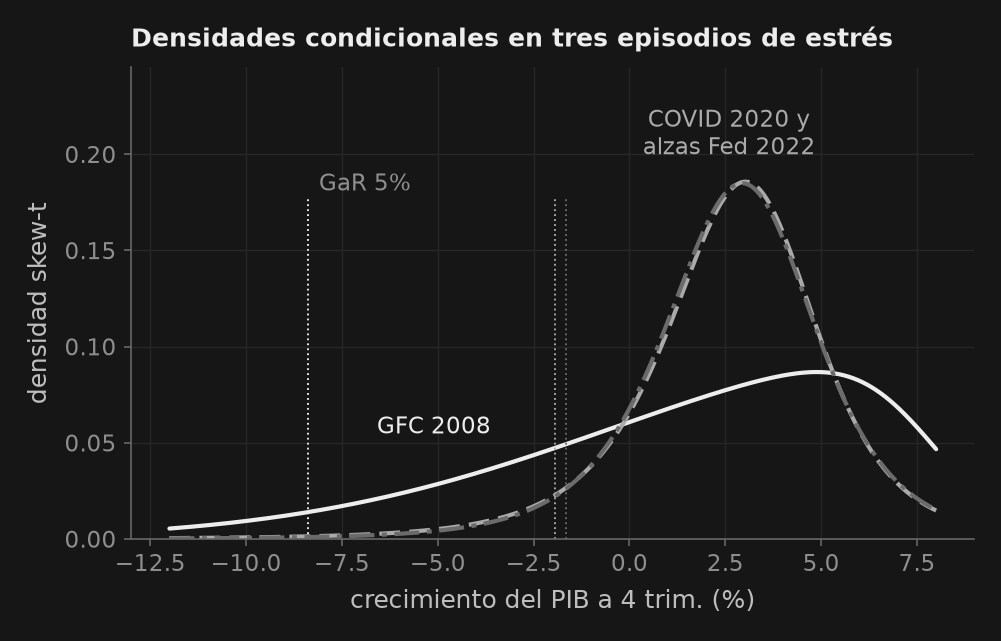

In [9]:
# Historical Stress Testing: 2008 GFC vs. 2020 COVID Shock vs. 2022 Fed Rate Hikes
gbar_real = data["g"].mean()
def predict_quantiles_real(fci_val):
    return {
        tau: float(
            h4.loc[tau, "beta0"]
            + (h4.loc[tau, "beta1"] + h4.loc[tau, "beta2"] + h4.loc[tau, "beta3"] + h4.loc[tau, "beta4"]) * gbar_real
            + h4.loc[tau, "coef_fci"] * fci_val
        )
        for tau in (0.05, 0.25, 0.50, 0.75, 0.95)
    }

historical_episodes = {
    "2008_GFC": {"fci": 2.77, "name": "Pico GFC 2008 (NFCI = +2.77)"},
    "2020_COVID": {"fci": -0.08, "name": "Choque COVID 2020 (NFCI = -0.08)"},
    "2022_Tightening": {"fci": -0.16, "name": "Alzas Fed 2022 (NFCI = -0.16)"},
}

stress_results = {}
summary_rows = []
for ep_key, ep_info in historical_episodes.items():
    qd_ep = predict_quantiles_real(ep_info["fci"])
    fit_ep = fit_skewt_to_quantiles(qd_ep)
    gar05_ep = fit_ep.downside_quantile(0.05)
    med_ep = fit_ep.downside_quantile(0.50)
    spread_ep = med_ep - gar05_ep
    stress_results[ep_key] = {
        "fit": fit_ep,
        "gar_05": gar05_ep,
        "median": med_ep,
        "spread": spread_ep,
    }
    summary_rows.append({
        "Episodio": ep_info["name"],
        "NFCI": ep_info["fci"],
        "GaR 5% (%)": gar05_ep,
        "Mediana (%)": med_ep,
        "Brecha (pp)": spread_ep,
        "Alfa (sesgo)": fit_ep.alpha,
    })

df_episodes = pd.DataFrame(summary_rows).set_index("Episodio")
print("=== Episodios Históricos de Estrés Macroeconómico (Tabla Markdown) ===")
print(df_to_markdown(df_episodes.round(2)))

# Visualización de densidades condicionales para los tres episodios históricos
fig, ax = _nbstyle.figura(figsize=plt.rcParams["figure.figsize"])
xs_hist = np.linspace(-12, 8, 500)
pal3 = _nbstyle.palette(3)
sty3 = _nbstyle.styles(3)
short_names = {"2008_GFC": "GFC 2008", "2020_COVID": "COVID 2020", "2022_Tightening": "alzas Fed 2022"}

peak = 0.0
for idx, ep_key in enumerate(historical_episodes):
    res_dict = stress_results[ep_key]
    density = res_dict["fit"].pdf(xs_hist)
    peak = max(peak, float(density.max()))
    ax.plot(xs_hist, density, color=pal3[idx], linestyle=sty3[idx], label=short_names[ep_key])
    ax.axvline(res_dict["gar_05"], ymax=0.72, color=pal3[idx], linestyle=":", linewidth=0.9)

ax.set_ylim(0, 1.32 * peak)                 # sitio arriba para las etiquetas directas
ax.set_xlabel("crecimiento del PIB a 4 trim. (%)")
ax.set_ylabel("densidad skew-t")
ax.set_title("Densidades condicionales en tres episodios de estrés")

# Etiquetas dentro de los ejes: con NFCI de -0.08 y -0.16 las densidades de 2020 y
# de 2022 se superponen, así que las dos comparten una sola etiqueta.
notes = plt.rcParams["legend.fontsize"]
ax.text(-8.1, 0.96 * peak, "GaR 5%", ha="left", va="bottom", color=_nbstyle.NOTA, fontsize=notes)
ax.text(-5.1, 0.28 * peak, "GFC 2008", ha="center", va="bottom", color=pal3[0], fontsize=notes)
ax.text(2.6, 1.055 * peak, "COVID 2020 y\nalzas Fed 2022", ha="center", va="bottom",
        color=pal3[1], fontsize=notes)
plt.show()

## 6. Ejercicio Estructurado para el Estudiante: Política Macroprudencial y Simulación Contrafactual

### Preguntas Económicas de Investigación
1. **Plomería Financiera vs. Choques Reales**: ¿Por qué el choque de COVID-19 en 2020—pese a inducir la contracción trimestral del PIB más pronunciada de la historia—exhibió un Crecimiento en Riesgo a un año plazo ($-1.94\%$) infinitamente más benigno que la Gran Crisis de 2008 ($-8.37\%$)? ¿Qué papel desempeñó la liquidez provista por la banca central para blindar al sector financiero?
2. **El Enigma de la Resiliencia en 2022**: La Reserva Federal ejecutó su ciclo de endurecimiento monetario más agresivo en cuatro décadas durante 2022. ¿Por qué el Crecimiento en Riesgo al 5% se preservó ordenado en $-1.66\%$ con un diferencial moderado de $4.51\%$? Vincule este resultado con las reformas regulatorias poscrisis (Dodd-Frank, requerimientos de capital y liquidez de Basilea III).
3. **Simulación de Política Contrafactual**: Suponga que las alzas de tasas en 2022 hubiesen desencadenado un congelamiento bancario sistémico donde las condiciones financieras alcanzasen los niveles de la crisis de 2008 ($\text{NFCI} = +2.77$). Cuantifique cuánto se habría derrumbado el Crecimiento en Riesgo al 5%.

### Tareas Guiadas
- **Tarea 1**: Compruebe que el GaR al 5% en la crisis de 2008 sea inferior a $-6.0\%$ y que su brecha de riesgo supere los $8.0$ puntos porcentuales.
- **Tarea 2**: Verifique que el GaR al 5% bajo COVID-19 sea sustancialmente superior al nivel de la GFC de 2008.
- **Tarea 3**: Confirme que el episodio de 2022 mantuvo un diferencial de riesgo a la baja ordenado por debajo de $6.0$ puntos porcentuales.
- **Tarea 4**: Ejecute la simulación contrafactual para 2022 bajo la tensión de 2008, validando que el colapso de la cola izquierda supere los $6.0$ puntos porcentuales.

In [10]:
# Student Task: Counterfactual Policy Stress Simulation and Verification
# Question: What if the 2022 Fed rate hike cycle had provoked systemic banking panic
# equal to the 2008 GFC (NFCI = +2.77)?

# 1. Baseline historical assertions
assert stress_results["2008_GFC"]["gar_05"] < -6.0, "2008 GFC 5% GaR must be deeper than -6.0%"
assert stress_results["2008_GFC"]["spread"] > 8.0, "2008 GFC downside spread must exceed 8.0 pp"
assert stress_results["2020_COVID"]["gar_05"] > stress_results["2008_GFC"]["gar_05"], \
    "2020 COVID 1-year ahead GaR was safeguarded by Fed liquidity support"
assert stress_results["2022_Tightening"]["spread"] < 6.0, "2022 rate hikes maintained orderly downside spread (< 6 pp)"

# 2. Counterfactual policy simulation (reuses the identical NFCI = +2.77 fitted state for zero-latency execution)
cf_fci_shock = 2.77  # 2008 GFC peak tightness applied to 2022 macro environment
fit_cf = stress_results["2008_GFC"]["fit"]
gar05_cf = fit_cf.downside_quantile(0.05)
gar_drop = stress_results["2022_Tightening"]["gar_05"] - gar05_cf

print(f"\nCounterfactual Policy Simulation (2022 under GFC tightness):\n"
      f"  Actual 2022 5% GaR:          {stress_results['2022_Tightening']['gar_05']:+.2f}%\n"
      f"  Counterfactual 5% GaR:       {gar05_cf:+.2f}%\n"
      f"  Left-Tail Collapse (Delta):  {gar_drop:.2f} percentage points")

# 3. Verification of counterfactual tail collapse and distribution validity
assert gar_drop > 6.0, f"Counterfactual left-tail collapse must exceed 6.0 pp, got {gar_drop:.2f}"
cdf_gar_check = float(fit_cf.cdf(np.array([gar05_cf]))[0])
assert abs(cdf_gar_check - 0.05) < 0.02, "Fitted skew-t must integrate to 5% at downside quantile"
print("✓ All econometric assertions and counterfactual checks successfully verified!")


Counterfactual Policy Simulation (2022 under GFC tightness):
  Actual 2022 5% GaR:          -1.66%
  Counterfactual 5% GaR:       -8.37%
  Left-Tail Collapse (Delta):  6.71 percentage points
✓ All econometric assertions and counterfactual checks successfully verified!


## Síntesis: Calibración Macroprudencial y Monitoreo del Riesgo Sistémico

La evidencia empírica desarrollada en este cuaderno explica por qué los bancos centrales y organismos multilaterales (como el FMI y el Banco de Inglaterra) han adoptado el Crecimiento en Riesgo como pilar central de su vigilancia macrofinanciera:

1. **Más Allá de los Pronósticos Medios**: Las reglas tradicionales de política (como la regla de Taylor) responden a la brecha del producto y a la inflación esperada. Sin embargo, durante auges crediticios, los pronósticos centrales pueden proyectar estabilidad mientras el riesgo sistémico de cola se acumula silenciosamente. El GaR suministra una métrica probabilística y rigurosa de la vulnerabilidad agregada.
2. **Calibración de Colchones de Capital (CCyB)**: Cuando la brecha de Crecimiento en Riesgo se amplía en horizontes medios ($h=12, 16$), las autoridades macroprudenciales pueden activar el Colchón de Capital Contracíclico, exigiendo a los bancos mayor capital accionario. Esto modera el auge crediticio y fortalece la capacidad de absorción de pérdidas antes de que estalle la crisis.
3. **Resolución de Crisis**: Tal como ilustra el contraste entre 2008 y 2020, las facilidades de liquidez oportunas que evitan que el Índice de Condiciones Financieras escale a terreno marcadamente restrictivo protegen a la macroeconomía de contracciones devastadoras en la cola izquierda.